# 🎨 Bài 5: Các Hệ Màu Cơ Bản Trong Xử Lý Ảnh (Colour Space)
**Môn học**: E1402 - Digital and Computer Vision

**Thời gian**: ~50 phút | **Trình độ**: Người mới bắt đầu

**Nguồn tham khảo**: [AI Tech - Các hệ màu cơ bản](https://buiduchanh.github.io/Colour-space-1/)

---

## 🎯 Mục tiêu bài học
Sau bài này, bạn sẽ:
1. Hiểu khái niệm **Không gian màu (Colour Space)** là gì
2. Nắm vững hệ màu **RGB** và **RGBA** — cách máy tính lưu trữ màu sắc
3. Hiểu hệ màu **HSV** — cách tự nhiên hơn để mô tả màu sắc
4. Phân biệt **ảnh xám (Grayscale)** và **ảnh nhị phân (Binary)**
5. Thực hành **lọc màu** bằng RGB vs HSV và thấy rõ ưu điểm của HSV
6. **Upload ảnh của bạn** để thực hành chuyển đổi không gian màu

> 💡 **Cách sử dụng**: Nhấn nút ▶️ Play ở mỗi ô code. Đọc giải thích → chạy code → quan sát kết quả → thử thay đổi tham số!

---
## 📖 Phần 1: Không Gian Màu (Colour Space) là gì?

**Không gian màu (Colour Space)** là các **mô hình toán học** để miêu tả màu sắc.

Mỗi không gian màu đều có một **tác dụng và ứng dụng** trong các bài toán khác nhau:

| Không gian màu | Đặc điểm | Ứng dụng chính |
|---|---|---|
| 🔴🟢🔵 **RGB** | 3 kênh: Red, Green, Blue | Hiển thị trên màn hình, lưu trữ ảnh |
| 🌈 **HSV** | Hue (vùng màu), Saturation (bão hòa), Value (độ sáng) | Lọc màu, nhận diện đối tượng theo màu |
| ⬛⬜ **Grayscale** | 1 kênh: Độ sáng (0-255) | Phát hiện cạnh, xử lý nhanh |
| ⚫⚪ **Binary** | 1 kênh: chỉ 0 hoặc 255 | Phân đoạn, lọc nhiễu, OCR |
| 🔴🟢🔵🔲 **RGBA** | RGB + kênh Alpha (độ trong suốt) | Ghép ảnh, watermark |

```
Ảnh gốc (RGB)         Ảnh HSV              Ảnh xám         Ảnh nhị phân
┌──────────┐       ┌──────────┐        ┌──────────┐     ┌──────────┐
│ R  G  B  │       │ H  S  V  │        │ Intensity│     │  0 / 255 │
│(255,0,0) │  →    │(0,255,255│   →    │   76     │  →  │   0      │
│  = Đỏ    │       │  = Đỏ    │        │  = Xám   │     │  = Đen   │
└──────────┘       └──────────┘        └──────────┘     └──────────┘
  3 kênh              3 kênh              1 kênh           1 kênh
```

> ⚠️ **Lưu ý quan trọng**: OpenCV đọc ảnh theo thứ tự **BGR** (Blue-Green-Red),
> khác với Matplotlib/Pillow dùng **RGB**. Cần chuyển đổi khi hiển thị!

## ⚙️ Cài đặt thư viện
Chạy ô này **một lần** để import các thư viện cần thiết.

In [8]:
import cv2                          # OpenCV - thư viện xử lý ảnh chính
import numpy as np                  # NumPy - xử lý ma trận số
import matplotlib.pyplot as plt     # Matplotlib - hiển thị ảnh/đồ thị
from urllib.request import urlopen, Request  # Tải ảnh từ internet
try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False
import io

# === HÀM HỖ TRỢ ===

def tai_anh_url(url):
    """Tải ảnh từ URL internet, trả về ảnh dạng BGR (OpenCV)"""
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urlopen(req)
    du_lieu = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    anh = cv2.imdecode(du_lieu, cv2.IMREAD_COLOR)
    return anh

def hien_thi(danh_sach_anh, danh_sach_tieu_de, figsize=(16, 5)):
    """Hiển thị nhiều ảnh cạnh nhau để so sánh"""
    fig, axes = plt.subplots(1, len(danh_sach_anh), figsize=figsize)
    if len(danh_sach_anh) == 1:
        axes = [axes]
    for ax, anh, tieu_de in zip(axes, danh_sach_anh, danh_sach_tieu_de):
        if len(anh.shape) == 2:  # Ảnh xám (1 kênh)
            ax.imshow(anh, cmap='gray')
        else:                     # Ảnh màu (3 kênh) - chuyển BGR→RGB
            ax.imshow(cv2.cvtColor(anh, cv2.COLOR_BGR2RGB))
        ax.set_title(tieu_de, fontsize=13, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('✅ Tất cả thư viện đã sẵn sàng!')
print(f'   OpenCV phiên bản: {cv2.__version__}')
print(f'   NumPy phiên bản:  {np.__version__}')

✅ Tất cả thư viện đã sẵn sàng!
   OpenCV phiên bản: 4.12.0
   NumPy phiên bản:  2.2.6


---
## 🔴🟢🔵 Phần 2: Hệ Màu RGB (Red - Green - Blue)

### 2.1 Nguyên lý cơ bản

RGB là không gian màu **phổ biến nhất** dùng trong máy tính, máy ảnh, điện thoại
và nhiều thiết bị kỹ thuật số. Nguyên lý khá gần với cách **mắt người tổng hợp màu sắc**.

**Nguyên lý**: Sử dụng 3 màu cơ bản:
- **R** (Red - Đỏ)
- **G** (Green - Xanh lục)
- **B** (Blue - Xanh lam)

để biểu diễn **tất cả** các màu sắc.

```
Mô hình màu RGB 24-bit:
┌─────────────────────────────────────┐
│  Mỗi kênh: 8 bit → giá trị 0-255   │
│                                     │
│  R = 0-255  (Cường độ đỏ)           │
│  G = 0-255  (Cường độ xanh lục)     │
│  B = 0-255  (Cường độ xanh lam)     │
│                                     │
│  Tổng số màu: 256 × 256 × 256      │
│             = 16,777,216 màu        │
└─────────────────────────────────────┘

Ví dụ một số màu:
(255, 0, 0)   = Đỏ thuần
(0, 255, 0)   = Xanh lục thuần
(0, 0, 255)   = Xanh lam thuần
(255, 255, 0) = Vàng
(255, 255, 255) = Trắng
(0, 0, 0)     = Đen
```

### 2.2 RGBA - RGB với kênh Alpha (Độ trong suốt)

**RGBA** thêm một kênh **Alpha (α)** vào RGB:
- α = 0% → Pixel **hoàn toàn trong suốt**
- α = 100% → Pixel **hoàn toàn mờ đục**

→ Ứng dụng: Ghép ảnh, tạo watermark, xử lý ảnh PNG có nền trong suốt.

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/3148549635.py:30: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/3148549635.py:30: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/3148549635.py:30: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


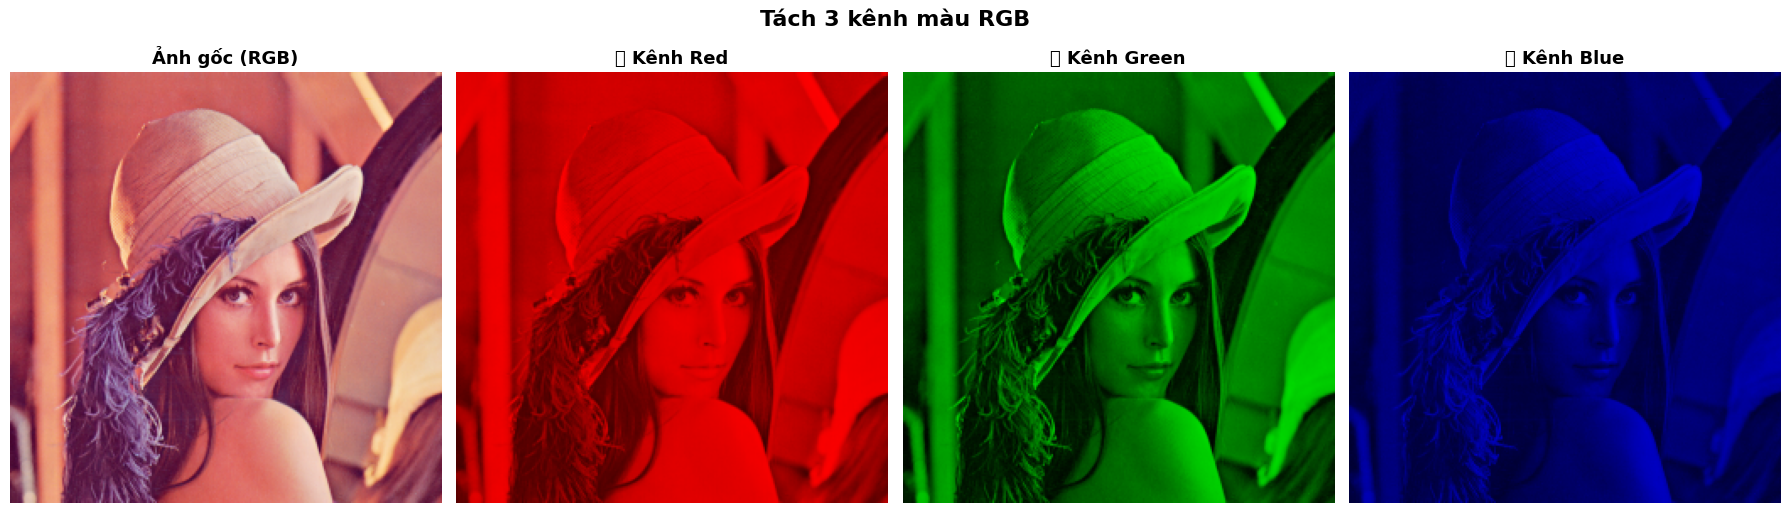


📋 Thông tin ảnh:
   Kích thước: (256, 256, 3)
   Mỗi kênh (B/G/R) có giá trị từ 4 đến 255


In [9]:
# === DEMO: Tách các kênh RGB và hiển thị ===
# Tải ảnh mẫu
url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png'
anh_goc = tai_anh_url(url)
anh_goc = cv2.resize(anh_goc, (256, 256))

# OpenCV lưu ảnh theo BGR → tách 3 kênh
B, G, R = cv2.split(anh_goc)

# Tạo ảnh chỉ hiển thị từng kênh riêng lẻ
zeros = np.zeros_like(B)  # Ma trận toàn 0 cùng kích thước

anh_chi_R = cv2.merge([zeros, zeros, R])  # Chỉ kênh Red
anh_chi_G = cv2.merge([zeros, G, zeros])  # Chỉ kênh Green
anh_chi_B = cv2.merge([B, zeros, zeros])  # Chỉ kênh Blue

# Hiển thị
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(anh_goc, cv2.COLOR_BGR2RGB))
axes[0].set_title('Ảnh gốc (RGB)', fontsize=13, fontweight='bold')
axes[1].imshow(cv2.cvtColor(anh_chi_R, cv2.COLOR_BGR2RGB))
axes[1].set_title('🔴 Kênh Red', fontsize=13, fontweight='bold')
axes[2].imshow(cv2.cvtColor(anh_chi_G, cv2.COLOR_BGR2RGB))
axes[2].set_title('🟢 Kênh Green', fontsize=13, fontweight='bold')
axes[3].imshow(cv2.cvtColor(anh_chi_B, cv2.COLOR_BGR2RGB))
axes[3].set_title('🔵 Kênh Blue', fontsize=13, fontweight='bold')
for ax in axes:
    ax.axis('off')
plt.suptitle('Tách 3 kênh màu RGB', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📋 Thông tin ảnh:')
print(f'   Kích thước: {anh_goc.shape}')
print(f'   Mỗi kênh (B/G/R) có giá trị từ {anh_goc.min()} đến {anh_goc.max()}')

---
## 🌈 Phần 3: Hệ Màu HSV (Hue - Saturation - Value)

### 3.1 Lý thuyết

HSV là cách **tự nhiên hơn** để mô tả màu sắc, dựa trên 3 thành phần:

| Thành phần | Ý nghĩa | Khoảng giá trị (OpenCV) |
|---|---|---|
| **H** (Hue) | **Vùng màu** - xác định màu gì (đỏ, xanh, vàng...) | 0 - 179 |
| **S** (Saturation) | **Độ bão hòa** - màu đậm hay nhạt | 0 - 255 |
| **V** (Value) | **Độ sáng** - sáng hay tối | 0 - 255 |

```
Bảng khoảng HSV cho các màu phổ biến (trong OpenCV):
┌──────────────┬────────────┬────────────┬────────────┐
│   Màu        │  H (min-max)│ S (min-max)│ V (min-max)│
├──────────────┼────────────┼────────────┼────────────┤
│ 🔴 Đỏ (thấp) │   0 - 10   │  100 - 255 │  100 - 255 │
│ 🔴 Đỏ (cao)  │ 160 - 179  │  100 - 255 │  100 - 255 │
│ 🟠 Cam       │  11 - 25   │  100 - 255 │  100 - 255 │
│ 🟡 Vàng      │  26 - 35   │  100 - 255 │  100 - 255 │
│ 🟢 Xanh lá   │  36 - 86   │  100 - 255 │  100 - 255 │
│ 🔵 Xanh dương│  87 - 130  │  100 - 255 │  100 - 255 │
│ 🟣 Tím       │ 131 - 159  │  100 - 255 │  100 - 255 │
└──────────────┴────────────┴────────────┴────────────┘
```

### 3.2 Tại sao HSV tốt hơn RGB trong lọc màu?

- **RGB**: Màu sắc bị phụ thuộc vào **ánh sáng** → cùng 1 vật, ánh sáng khác nhau thì RGB khác nhau rất nhiều
- **HSV**: **Hue** (vùng màu) **ổn định** dù ánh sáng thay đổi → lọc màu chính xác hơn

> 💡 **Trong thực tế**, các bài toán nhận dạng màu, tracking vật thể theo màu **luôn ưu tiên HSV** thay vì RGB.

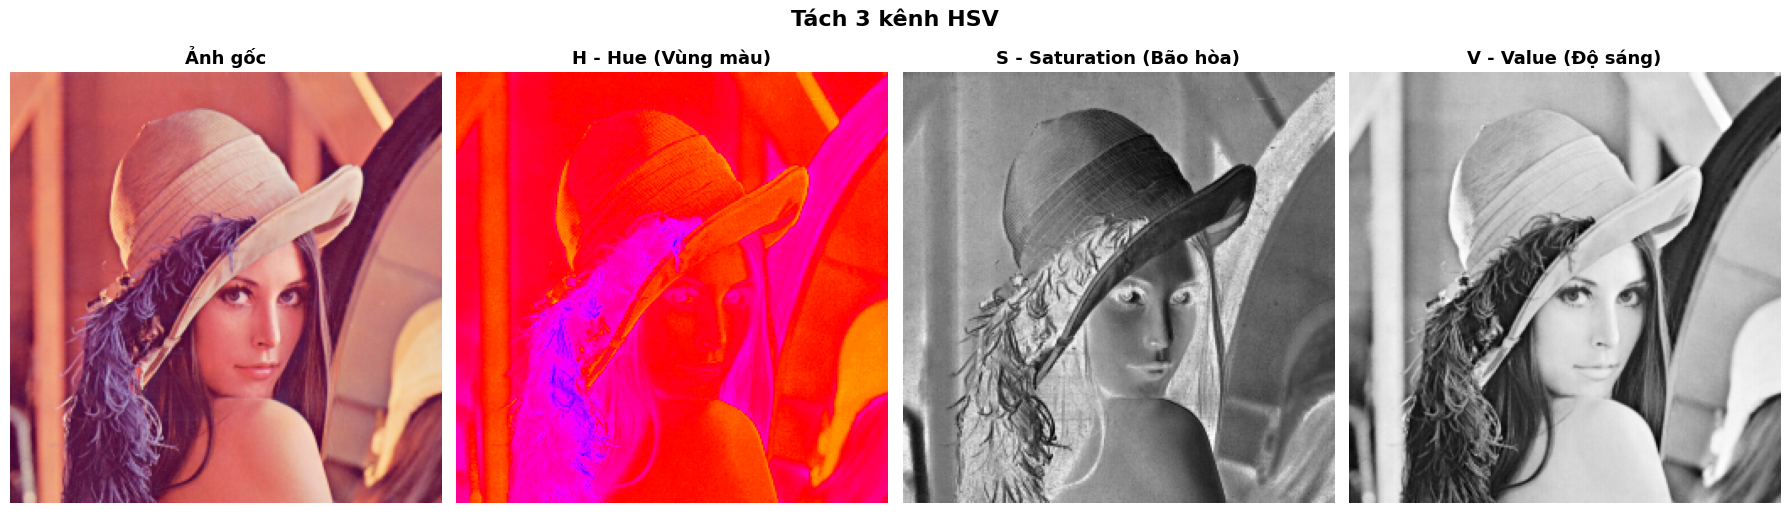

📋 Khoảng giá trị HSV trong ảnh:
   H (Hue):        0 - 179
   S (Saturation):  19 - 242
   V (Value):       61 - 255


In [10]:
# === DEMO: Chuyển đổi RGB → HSV và tách các kênh ===

# Chuyển BGR → HSV
anh_hsv = cv2.cvtColor(anh_goc, cv2.COLOR_BGR2HSV)

# Tách 3 kênh HSV
H, S, V = cv2.split(anh_hsv)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(anh_goc, cv2.COLOR_BGR2RGB))
axes[0].set_title('Ảnh gốc', fontsize=13, fontweight='bold')
axes[1].imshow(H, cmap='hsv')  # Dùng colormap hsv cho kênh Hue
axes[1].set_title('H - Hue (Vùng màu)', fontsize=13, fontweight='bold')
axes[2].imshow(S, cmap='gray')
axes[2].set_title('S - Saturation (Bão hòa)', fontsize=13, fontweight='bold')
axes[3].imshow(V, cmap='gray')
axes[3].set_title('V - Value (Độ sáng)', fontsize=13, fontweight='bold')
for ax in axes:
    ax.axis('off')
plt.suptitle('Tách 3 kênh HSV', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'📋 Khoảng giá trị HSV trong ảnh:')
print(f'   H (Hue):        {H.min()} - {H.max()}')
print(f'   S (Saturation):  {S.min()} - {S.max()}')
print(f'   V (Value):       {V.min()} - {V.max()}')

---
## 🔬 Phần 4: So sánh lọc màu — RGB vs HSV

Đây là **ứng dụng điển hình nhất** của HSV: **lọc màu** (color filtering).

### Bài toán: Lọc màu xanh lá cây từ ảnh đèn giao thông

Chúng ta sẽ thử lọc màu xanh bằng cả 2 hệ màu RGB và HSV để so sánh hiệu quả.

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/140274726.py:34: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


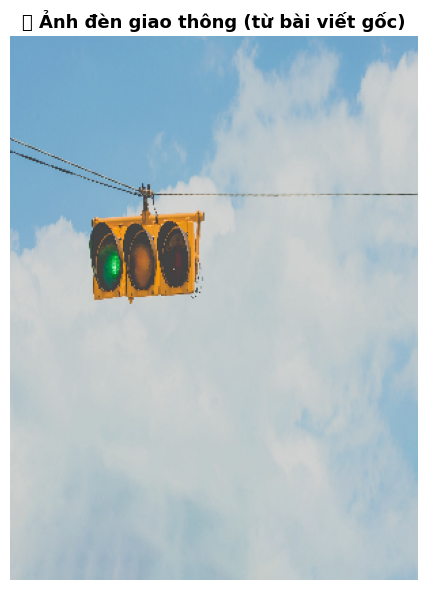

📋 Kích thước ảnh: (400, 300, 3)


In [11]:
# === Tải ảnh đèn giao thông thực tế từ bài viết gốc ===
url_den = 'https://buiduchanh.github.io/assets/images/colour_space/traffic_light.jpeg'
anh_den = tai_anh_url(url_den)

# Resize cho vừa hiển thị
anh_den = cv2.resize(anh_den, (300, 400))

hien_thi([anh_den], ['🚦 Ảnh đèn giao thông (từ bài viết gốc)'], figsize=(5, 6))
print(f'📋 Kích thước ảnh: {anh_den.shape}')

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/3419586427.py:34: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/3419586427.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6063/3419586427.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


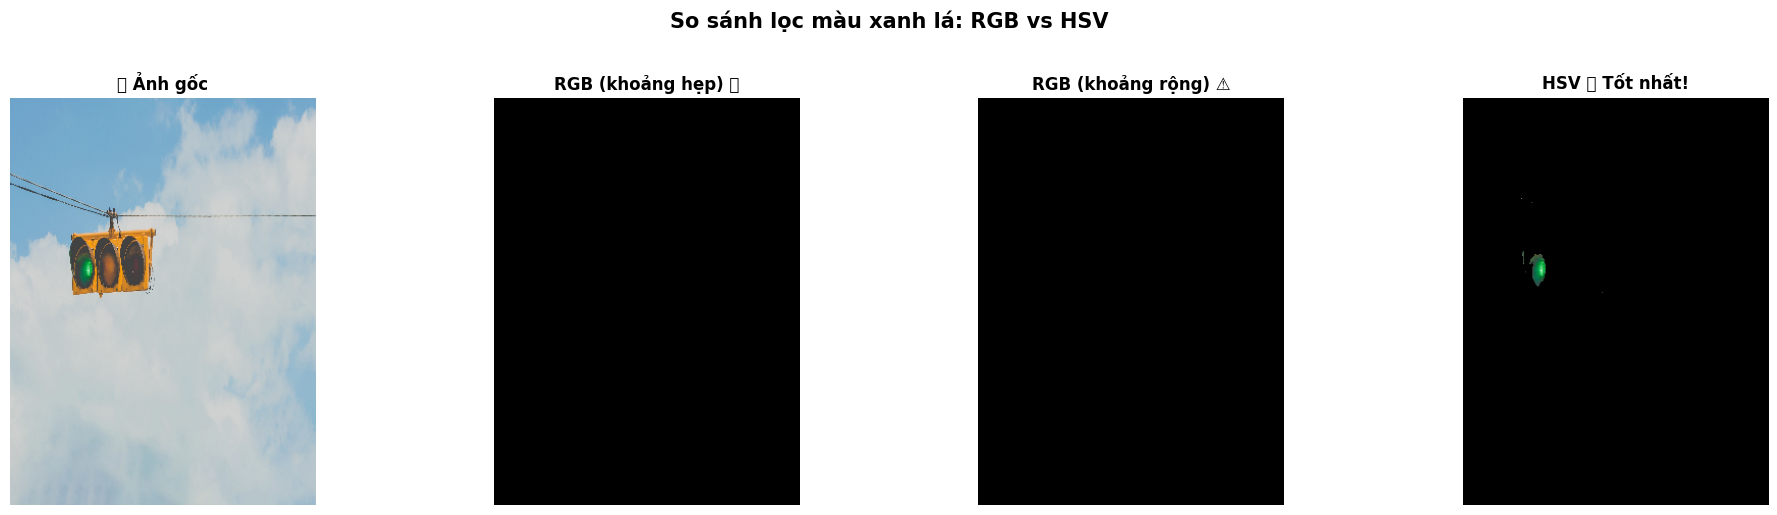

📊 Kết quả so sánh:
   RGB (hẹp):  Pixel xanh tìm được = 0
   RGB (rộng): Pixel xanh tìm được = 0
   HSV:        Pixel xanh tìm được = 359

💡 HSV hoạt động tốt hơn RGB trong lọc màu vì Hue ổn định dù ánh sáng thay đổi!


In [12]:
# === THỬ LỌC MÀU BẰNG RGB ===
# Thử 1: Khoảng hẹp
lower_green_rgb = np.array([0, 220, 0])    # BGR trong OpenCV
upper_green_rgb = np.array([50, 255, 50])
mask_rgb_1 = cv2.inRange(anh_den, lower_green_rgb, upper_green_rgb)
result_rgb_1 = cv2.bitwise_and(anh_den, anh_den, mask=mask_rgb_1)

# Thử 2: Khoảng rộng hơn
lower_green_rgb2 = np.array([0, 200, 0])
upper_green_rgb2 = np.array([70, 255, 70])
mask_rgb_2 = cv2.inRange(anh_den, lower_green_rgb2, upper_green_rgb2)
result_rgb_2 = cv2.bitwise_and(anh_den, anh_den, mask=mask_rgb_2)

# === LỌC MÀU BẰNG HSV ===
anh_hsv_den = cv2.cvtColor(anh_den, cv2.COLOR_BGR2HSV)
lower_green_hsv = np.array([36, 50, 50])
upper_green_hsv = np.array([86, 255, 255])
mask_hsv = cv2.inRange(anh_hsv_den, lower_green_hsv, upper_green_hsv)
result_hsv = cv2.bitwise_and(anh_den, anh_den, mask=mask_hsv)

# So sánh kết quả
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(anh_den, cv2.COLOR_BGR2RGB))
axes[0].set_title('🚦 Ảnh gốc', fontsize=12, fontweight='bold')
axes[1].imshow(cv2.cvtColor(result_rgb_1, cv2.COLOR_BGR2RGB))
axes[1].set_title('RGB (khoảng hẹp) ❌', fontsize=12, fontweight='bold')
axes[2].imshow(cv2.cvtColor(result_rgb_2, cv2.COLOR_BGR2RGB))
axes[2].set_title('RGB (khoảng rộng) ⚠️', fontsize=12, fontweight='bold')
axes[3].imshow(cv2.cvtColor(result_hsv, cv2.COLOR_BGR2RGB))
axes[3].set_title('HSV ✅ Tốt nhất!', fontsize=12, fontweight='bold')
for ax in axes:
    ax.axis('off')
plt.suptitle('So sánh lọc màu xanh lá: RGB vs HSV', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📊 Kết quả so sánh:')
print(f'   RGB (hẹp):  Pixel xanh tìm được = {np.count_nonzero(mask_rgb_1)}')
print(f'   RGB (rộng): Pixel xanh tìm được = {np.count_nonzero(mask_rgb_2)}')
print(f'   HSV:        Pixel xanh tìm được = {np.count_nonzero(mask_hsv)}')
print('\n💡 HSV hoạt động tốt hơn RGB trong lọc màu vì Hue ổn định dù ánh sáng thay đổi!')

---
## ⬛⬜ Phần 5: Ảnh Xám (Grayscale) và Ảnh Nhị Phân (Binary)

### 5.1 Ảnh xám (Grayscale)

Ảnh xám là ảnh trong đó mỗi pixel chỉ có **1 giá trị** (0-255) biểu diễn **độ sáng**.

- **Ưu điểm**: Giảm khối lượng thông tin (1 kênh thay vì 3) → **xử lý nhanh hơn**
- **Ứng dụng**: Phát hiện cạnh, nhận dạng khuôn mặt, OCR, ...

### 5.2 Ảnh nhị phân (Binary)

Ảnh nhị phân là ảnh trong đó mỗi pixel chỉ có giá trị **0 (đen)** hoặc **255 (trắng)**.

- **Ưu điểm**: Thể hiện rõ **góc cạnh và hình dáng** vật thể
- **Ứng dụng**: Phân đoạn ảnh, lọc nhiễu, phát hiện vật thể

```
Ảnh gốc (3 kênh)    →    Ảnh xám (1 kênh)    →    Ảnh nhị phân (0/255)
┌──────────┐           ┌──────────┐             ┌──────────┐
│(R, G, B) │    →      │    L     │      →      │  0/255   │
│ 3 byte   │           │  1 byte  │             │  1 bit   │
│/pixel    │           │ /pixel   │             │ /pixel   │
└──────────┘           └──────────┘             └──────────┘
  Đầy đủ info        Giảm 66% data            Tối giản nhất
```

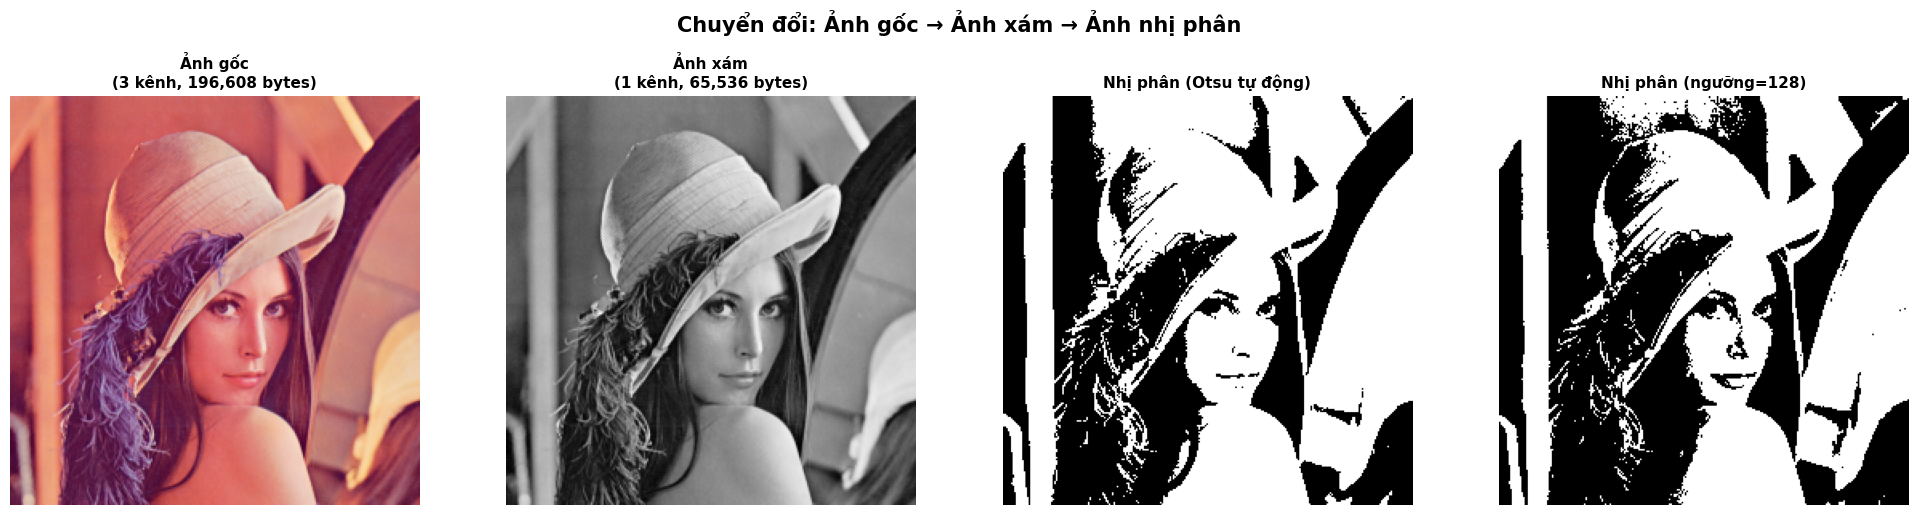

📋 So sánh kích thước dữ liệu:
   Ảnh gốc (RGB):          196,608 bytes
   Ảnh xám (Grayscale):     65,536 bytes  (giảm 67%)
   Ảnh nhị phân: cũng       65,536 bytes nhưng chỉ có 2 giá trị (0, 255)


In [13]:
# === DEMO: Chuyển đổi Ảnh gốc → Ảnh xám → Ảnh nhị phân ===

# 1. Ảnh xám
anh_xam = cv2.cvtColor(anh_goc, cv2.COLOR_BGR2GRAY)

# 2. Ảnh nhị phân (dùng ngưỡng Otsu - tự động tìm ngưỡng tốt nhất)
_, anh_nhi_phan = cv2.threshold(anh_xam, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Ảnh nhị phân với ngưỡng cố định
_, anh_nhi_phan_128 = cv2.threshold(anh_xam, 128, 255, cv2.THRESH_BINARY)

# Hiển thị
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(anh_goc, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Ảnh gốc\n(3 kênh, {anh_goc.nbytes:,} bytes)', fontsize=11, fontweight='bold')
axes[1].imshow(anh_xam, cmap='gray')
axes[1].set_title(f'Ảnh xám\n(1 kênh, {anh_xam.nbytes:,} bytes)', fontsize=11, fontweight='bold')
axes[2].imshow(anh_nhi_phan, cmap='gray')
axes[2].set_title('Nhị phân (Otsu tự động)', fontsize=11, fontweight='bold')
axes[3].imshow(anh_nhi_phan_128, cmap='gray')
axes[3].set_title('Nhị phân (ngưỡng=128)', fontsize=11, fontweight='bold')
for ax in axes:
    ax.axis('off')
plt.suptitle('Chuyển đổi: Ảnh gốc → Ảnh xám → Ảnh nhị phân', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'📋 So sánh kích thước dữ liệu:')
print(f'   Ảnh gốc (RGB):       {anh_goc.nbytes:>10,} bytes')
print(f'   Ảnh xám (Grayscale): {anh_xam.nbytes:>10,} bytes  (giảm {(1-anh_xam.nbytes/anh_goc.nbytes)*100:.0f}%)')
print(f'   Ảnh nhị phân: cũng   {anh_nhi_phan.nbytes:>10,} bytes nhưng chỉ có 2 giá trị (0, 255)')

---
## 🧪 Phần 6: Thực hành — Upload ảnh của bạn

Bây giờ bạn hãy **upload ảnh của mình** để thực hành tất cả các chuyển đổi không gian màu!

In [14]:
# === UPLOAD ẢNH CỦA BẠN ===
if COLAB:
    print('📤 Hãy upload một ảnh từ máy tính của bạn:')
    uploaded = files.upload()
    ten_file = list(uploaded.keys())[0]
    du_lieu = np.asarray(bytearray(uploaded[ten_file]), dtype=np.uint8)
    anh_upload = cv2.imdecode(du_lieu, cv2.IMREAD_COLOR)
else:
    print('⚠️ Không dùng Colab → Sử dụng ảnh mẫu từ internet')
    anh_upload = tai_anh_url('https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/Image_created_with_a_mobile_phone.png/800px-Image_created_with_a_mobile_phone.png')

# Resize cho vừa hiển thị
max_size = 400
h, w = anh_upload.shape[:2]
if max(h, w) > max_size:
    scale = max_size / max(h, w)
    anh_upload = cv2.resize(anh_upload, (int(w*scale), int(h*scale)))

print(f'✅ Ảnh đã tải: {anh_upload.shape[1]}×{anh_upload.shape[0]} pixels')

⚠️ Không dùng Colab → Sử dụng ảnh mẫu từ internet


HTTPError: HTTP Error 429: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913)

In [ ]:
# === TỔNG HỢP: Hiển thị ảnh qua TẤT CẢ các không gian màu ===

# Chuyển đổi
anh_rgb = cv2.cvtColor(anh_upload, cv2.COLOR_BGR2RGB)
anh_hsv_up = cv2.cvtColor(anh_upload, cv2.COLOR_BGR2HSV)
anh_xam_up = cv2.cvtColor(anh_upload, cv2.COLOR_BGR2GRAY)
_, anh_bin_up = cv2.threshold(anh_xam_up, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Tách các kênh
H_up, S_up, V_up = cv2.split(anh_hsv_up)
B_up, G_up, R_up = cv2.split(anh_upload)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Hàng 1: Các không gian màu
axes[0][0].imshow(anh_rgb)
axes[0][0].set_title('Ảnh gốc (RGB)', fontsize=12, fontweight='bold')
axes[0][1].imshow(anh_xam_up, cmap='gray')
axes[0][1].set_title('Ảnh xám', fontsize=12, fontweight='bold')
axes[0][2].imshow(anh_bin_up, cmap='gray')
axes[0][2].set_title('Ảnh nhị phân', fontsize=12, fontweight='bold')
axes[0][3].imshow(H_up, cmap='hsv')
axes[0][3].set_title('Kênh H (Hue)', fontsize=12, fontweight='bold')

# Hàng 2: Các kênh riêng lẻ
axes[1][0].imshow(R_up, cmap='Reds')
axes[1][0].set_title('🔴 Kênh R', fontsize=12, fontweight='bold')
axes[1][1].imshow(G_up, cmap='Greens')
axes[1][1].set_title('🟢 Kênh G', fontsize=12, fontweight='bold')
axes[1][2].imshow(B_up, cmap='Blues')
axes[1][2].set_title('🔵 Kênh B', fontsize=12, fontweight='bold')
axes[1][3].imshow(S_up, cmap='gray')
axes[1][3].set_title('Kênh S (Saturation)', fontsize=12, fontweight='bold')

for row in axes:
    for ax in row:
        ax.axis('off')

plt.suptitle('🎨 Tổng hợp: Ảnh của bạn qua các không gian màu', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🎯 Phần 7: Thử nghiệm — Lọc màu tùy chọn bằng HSV

Hãy thử thay đổi các giá trị ngưỡng HSV để lọc các màu khác nhau!

**Hướng dẫn**: Thay đổi `mau_chon` thành: `'do'`, `'xanh_la'`, `'xanh_duong'`, `'vang'`

In [15]:
# === THỬ NGHIỆM: Lọc màu tùy chọn ===

# 🔧 THAY ĐỔI Ở ĐÂY: Chọn màu muốn lọc
mau_chon = 'do'  # Thử: 'do', 'xanh_la', 'xanh_duong', 'vang', 'cam'

# Bảng ngưỡng HSV cho từng màu
bang_mau = {
    'do':          {'lower1': [0, 100, 100], 'upper1': [10, 255, 255],
                    'lower2': [160, 100, 100], 'upper2': [179, 255, 255]},
    'cam':         {'lower1': [11, 100, 100], 'upper1': [25, 255, 255]},
    'vang':        {'lower1': [26, 100, 100], 'upper1': [35, 255, 255]},
    'xanh_la':     {'lower1': [36, 50, 50],   'upper1': [86, 255, 255]},
    'xanh_duong':  {'lower1': [87, 50, 50],   'upper1': [130, 255, 255]},
}

# Thực hiện lọc màu
anh_hsv_filter = cv2.cvtColor(anh_upload, cv2.COLOR_BGR2HSV)
cfg = bang_mau[mau_chon]
mask = cv2.inRange(anh_hsv_filter, np.array(cfg['lower1']), np.array(cfg['upper1']))

# Màu đỏ có 2 khoảng (quanh 0 và quanh 179)
if 'lower2' in cfg:
    mask2 = cv2.inRange(anh_hsv_filter, np.array(cfg['lower2']), np.array(cfg['upper2']))
    mask = cv2.bitwise_or(mask, mask2)

ket_qua = cv2.bitwise_and(anh_upload, anh_upload, mask=mask)

# Hiển thị
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(anh_upload, cv2.COLOR_BGR2RGB))
axes[0].set_title('Ảnh gốc', fontsize=13, fontweight='bold')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Mask (vùng màu "{mau_chon}")', fontsize=13, fontweight='bold')
axes[2].imshow(cv2.cvtColor(ket_qua, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Kết quả lọc màu "{mau_chon}"', fontsize=13, fontweight='bold')
for ax in axes:
    ax.axis('off')
plt.suptitle(f'🔬 Lọc màu "{mau_chon}" bằng HSV', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'📊 Số pixel tìm được: {np.count_nonzero(mask):,} / {mask.size:,} ({np.count_nonzero(mask)/mask.size*100:.1f}%)')

NameError: name 'anh_upload' is not defined

---
## 📝 Tổng kết

### Bảng so sánh các hệ màu:

| Hệ màu | Số kênh | Khi nào dùng? | Ưu điểm | Nhược điểm |
|---|---|---|---|---|
| **RGB** | 3 | Hiển thị, lưu trữ | Trực quan, phổ biến | Nhạy cảm với ánh sáng |
| **HSV** | 3 | Lọc/nhận diện màu | Ổn định với ánh sáng | Khó trực quan hóa |
| **Grayscale** | 1 | Tiền xử lý, phát hiện cạnh | Nhanh, nhẹ | Mất thông tin màu |
| **Binary** | 1 | Phân đoạn, OCR | Rõ ràng, đơn giản | Mất nhiều chi tiết |

### Kiến thức cốt lõi:
1. ✅ OpenCV đọc ảnh theo **BGR**, cần chuyển sang RGB khi hiển thị với Matplotlib
2. ✅ **HSV** hiệu quả hơn RGB trong bài toán **lọc màu** vì Hue ổn định dù ánh sáng thay đổi
3. ✅ Ảnh xám giúp **giảm 66%** dữ liệu, phù hợp cho xử lý nhanh
4. ✅ Ảnh nhị phân làm rõ **hình dáng vật thể**, hữu ích cho phát hiện đối tượng

### Tham khảo:
- [Bài viết gốc - AI Tech](https://buiduchanh.github.io/Colour-space-1/)
- [Code mẫu trên GitHub](https://github.com/buiduchanh/Opencv_tutorial/tree/master/Colour_space)
- [Why we should use HSV?](https://dsp.stackexchange.com/questions/2687/why-do-we-use-the-hsv-colour-space-so-often-in-vision-and-image-processing)